In [1]:
from langchain_openai import ChatOpenAI

# 모델 초기화
model = ChatOpenAI(model="gpt-4o", temperature=0.01)
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-C4HmXW4o8ccEz8hS2N3NjBEBCOiLP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--83efa5b8-bd85-46f9-8632-1c6208705de2-0', usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다. 
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) 

In [3]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2025-08-14 11:15:29'

In [5]:

tools[1].invoke({"query": "파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m


c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


1. snippet: The official home of the Python Programming Language, title: Welcome to Python.org, link: https://www.python.org/
2. snippet: 점프 투 파이썬: 위키독스의 내용을 엮어서 낸 파이썬 입문 서적. 기초적인 내용을 다루며 비전문가가 따라가기 쉽게 되어 있다., title: Python - 나무위키, link: https://namu.wiki/w/Python
3. snippet: 파이썬 개발 환경 설정 파이썬은 쉽고 강력한 프로그래밍 언어로, 데이터 분석, 웹 개발, 인공지능 등 다양한 분야에서 사용됩니다., title: # 파이썬 기초부터 심화까지: 자세한 설명과 풍부한 예제 코드, link: https://velog.io/@gogocomputer/Python-Basics-to-Advanced
4. snippet: 파이썬 (Python)은 1991년 네덜란드의 프로그래머인 귀도 반 로섬 (Guido van Rossum)께서 개발한 고수준 (high-level) 프로그래밍 언어입니다., title: 파이썬 코리아 | 파이썬 소개, link: https://python.co.kr/pub/intro


'snippet: The official home of the Python Programming Language, title: Welcome to Python.org, link: https://www.python.org/;\nsnippet: 점프 투 파이썬: 위키독스의 내용을 엮어서 낸 파이썬 입문 서적. 기초적인 내용을 다루며 비전문가가 따라가기 쉽게 되어 있다., title: Python - 나무위키, link: https://namu.wiki/w/Python;\nsnippet: 파이썬 개발 환경 설정 파이썬은 쉽고 강력한 프로그래밍 언어로, 데이터 분석, 웹 개발, 인공지능 등 다양한 분야에서 사용됩니다., title: # 파이썬 기초부터 심화까지: 자세한 설명과 풍부한 예제 코드, link: https://velog.io/@gogocomputer/Python-Basics-to-Advanced;\nsnippet: 파이썬 (Python)은 1991년 네덜란드의 프로그래머인 귀도 반 로섬 (Guido van Rossum)께서 개발한 고수준 (high-level) 프로그래밍 언어입니다., title: 파이썬 코리아 | 파이썬 소개, link: https://python.co.kr/pub/intro'

In [6]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x000001BEA6843920>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x000001BEA694C680>


In [7]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [8]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:    # ①
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):    # ②
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:    # ③
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [9]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()

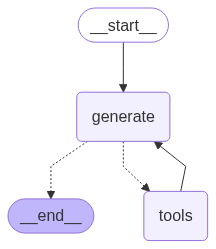

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

지금 서울은 2025년 8월 14일 오전 11시 16분입니다.

AIMessageChunk(content='지금 서울은 2025년 8월 14일 오전 11시 16분입니다.', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_DO19fKhdT8YWSG73PlLf3ldw', 'function': {'arguments': '{"timezone":"Asia/Seoul","location":"서울"}', 'name': 'get_current_time'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_callsstop', 'model_name': 'gpt-4o-2024-08-06gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8fp_07871e2ad8', 'service_tier': 'defaultdefault'}, id='run--d7b9c097-8469-43df-a6a5-af34e9b314e4', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'Asia/Seoul', 'location': '서울'}, 'id': 'call_DO19fKhdT8YWSG73PlLf3ldw', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'get_current_time', 'args': '{"timezone":"Asia/Seoul","location":"서울"}', 'id': 'call_DO19fKhdT8YWSG73PlLf3ldw', 'index': 0, 'type': 'tool_call_chunk'}])

In [12]:
from langchain_core.messages import AIMessageChunk, SystemMessage

about = "서울월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다. 
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.  

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
- 검색할 리스트를 토대로 재검색을 한다. 
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다. 
    
""")]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')


-------- WEB SEARCH --------
서울월드컵 경기장 잔디 문제
m


c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


1. snippet: 3 days ago · [서울=뉴시스] 박대로 기자 = 축구 국가대표팀 주장 손흥민의 잉글랜드 프로축구 프리미어리그(EPL) 토트넘 홋스퍼 고별전이 치러진 서울월드컵 ..., title: 손흥민 고별전에 잔디 불만 없었다…비판했던 축구팬 '엄지 척', link: https://www.newsis.com/view/NISX20250808_0003284340
2. snippet: Jul 31, 2025 · 국내 축구장 고질적 문제로 꼽히는 잔디가 또 말썽이었다. 경기장 곳곳에서 파인 잔디와 색이 변한 모습이 포착됐다. 수원월드컵경기장은 지난해 7월 그라운드 보수 공사를 …, title: 선수도 "잔디 최악" 또 논란…4개월 만에 엉망 된 '빅버드', link: https://www.fmkorea.com/8724600698
3. snippet: Jul 31, 2025 · 무리한 일정으로 우려가 제기됐던 수원월드컵경기장의 잔디 문제는 시리즈의 유일한 옥에 티였다. 김판곤 (감독)·이정효 (수석 코치) 감독이 이끄는 팀 K리그는 30일 오후 …, title: 팀 K리그, 뉴캐슬에 1-0 승리... 또 불거진 수원월드컵경기장 잔디 ..., link: https://star.ohmynews.com/NWS_Web/OhmyStar/at_pg.aspx?CNTN_CD=A0003152984
4. snippet: Aug 2, 2025 · 쿠팡플레이 시리즈 뉴캐슬전에서 발생한 수원 월드컵 경기장 잔디 사태 는 단순한 잔디 문제가 아닙니다. 11억 원을 들여 잔디를 가꾼 구단의 노력을 무시하고, 홈팬들의 추억이 …, title: 뉴캐슬전 잔디 대참사, 11억 들인 수원 경기장 잔디가 망가진 ..., link: https://koreaamateursports.tistory.com/entry/뉴캐슬전-잔디-대참사-11억-들인-수원-경기장-잔디가-망가진-충격적-이유
최근 서울월드컵 경기장의 잔디 문제가 큰 이슈가 되고 있습니다. 특히, 잉글랜드 프리미어리그(EPL) 토트넘

c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


1. snippet: Oct 16, 2024 · 동행·매력 특별시 서울의 주요뉴스, 시민참여, 주요서비스, 참여 신청, 행사 및 축제, 자주찾은서비스, 시장실, 분야별정보, 새소식, 서울영상, 서울소식, 서울녹서등의 정보제공, title: 서울특별시 - 동행·매력 특별시 서울, link: http://seoul.go.kr/
2. snippet: 서울 은 (는) 여기로 연결됩니다. 다른 뜻에 대한 내용은 서울 (동음이의어) 문서를 참고하십시오. 대한민국광역자치단체 특별시 서울특별시 광역시 부산광역시 대구광역시 인천광역시 광주광역시 대전광역시 …, title: 서울특별시 - 나무위키, link: https://namu.wiki/w/서울특별시
3. snippet: 서울 한양도성 조선시대 수도 한양을 둘러싸던 성곽으로, 도심 속에서 역사와 자연을 함께 느낄 수 있는 산책 명소 186 reviews, title: 서울 가볼만한 관광 명소 | 서울 공식 관광정보 웹사이트 - Seoul, link: https://korean.visitseoul.net/attractions
4. snippet: Jul 20, 2025 · 서울특별시 (서울特別市, 영어: Seoul Metropolitan City)는 사실상 대한민국 의 수도 이자 문화·인문·정치·경제 중심지 역할을 하는 도시로, 경기도 와 인천광역시 까지 아우르는 수도권 의 중심지 …, title: 서울특별시 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/서울특별시

-------- WEB SEARCH --------
기후 변화 잔디 상태 영향
m
1. snippet: 지구의 기후 시스템은 크게 보아 대기권, 수권, 설빙권, 생물권, 지권 등으로 구성된다. 기후 시스템을 움직이는 에너지 의 99.98%는 태양 에서 공급되며, 그 외의 에너지는 지구 내부와 지표에서 공급된다. 따라서 …, title: 기후 - 위키백과, 우리 모두의 백과사전, link: https://ko

...

1. snippet: Oct 16, 2024 · 동행·매력 특별시 서울의 주요뉴스, 시민참여, 주요서비스, 참여 신청, 행사 및 축제, 자주찾은서비스, 시장실, 분야별정보, 새소식, 서울영상, 서울소식, 서울녹서등의 정보제공, title: 서울특별시 - 동행·매력 특별시 서울, link: http://seoul.go.kr/
2. snippet: 서울 은 (는) 여기로 연결됩니다. 다른 뜻에 대한 내용은 서울 (동음이의어) 문서를 참고하십시오. 대한민국광역자치단체 특별시 서울특별시 광역시 부산광역시 대구광역시 인천광역시 …, title: 서울특별시 - 나무위키, link: https://namu.wiki/w/서울특별시
3. snippet: 서울 한양도성 조선시대 수도 한양을 둘러싸던 성곽으로, 도심 속에서 역사와 자연을 함께 느낄 수 있는 산책 명소 186 reviews, title: 서울 가볼만한 관광 명소 | 서울 공식 관광정보 웹사이트 - Seoul, link: https://korean.visitseoul.net/attractions
4. snippet: Jul 20, 2025 · 서울특별시 (서울特別市, 영어: Seoul Metropolitan City)는 사실상 대한민국 의 수도 이자 문화·인문·정치·경제 중심지 역할을 하는 도시로, 경기도 와 인천광역시 까지 아우르는 …, title: 서울특별시 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/서울특별시

-------- WEB SEARCH --------
해외 경기장 잔디 관리 사례
m
1. snippet: Apr 20, 2001 · 오늘 여행톡톡에서는 주요 해외여행지별 추천하는 여행시기와 추천하지 않는 여행시기를 정리해 공유했는데요. 월별 해외여행지 추천을 참고해 평소 쉽게 떠나기 힘든 해외여행인만큼 날씨로 인해 기분을 …, title: 월별 해외 여행지 추천 총정리 (2024ver) - 네이버 블로그, link: https://m.blog.n

c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


1. snippet: 잔디소개 고객사례 요금안내 도입문의 리소스 협업툴 블로그 다운로드 로그인, title: 협업툴 잔디 (JANDI) - AI로 진화한 메신저 기반 업무용 협업툴, link: https://www.jandi.com/landing/kr
2. snippet: Apr 15, 2006 · 이번 글에서는 한국에서 자주 사용하는 대표적인 잔디 종류들을 상세하게 소개하고, 그 특징, 장단점, 추천 사용처까지 한눈에 확인하실 수 있도록 정리해 드리겠습니다., title: 한국에서 주로 사용하는 잔디 종류 총정리 - 네이버 블로그, link: https://blog.naver.com/onyang2005/223888361772
3. snippet: Mar 18, 2025 · 잘 가꾸어진 잔디밭은 토양을 보호하고 공기 정화에 기여하며, 온도 조절 효과도 있어 생활 환경을 더욱 쾌적하게 만듭니다. 하지만 건강한 잔디밭을 조성하기 위해서는 적절한 잔디 종류를 선택하고, 최적의 …, title: 잔디 심는 시기와 관리 방법 알아 보자, link: https://geniuskang.tistory.com/entry/잔디-심는-시기와-관리-방법-알아-보자
4. snippet: 잔디밭을 푸르고 건강하게 유지하려면 계절과 월별로 세심한 관리가 필요합니다. 이 글은 잔디 식재 후 초기 관리부터 월별 관리법, 물주기, 비료 주기, 깎기, 잡초 제거, 병해충 방제, 토양 관리까지 최신 정보를 상세히 …, title: 잔디 관리요령과 월별 관리방법, link: https://google.nongsaro.co.kr/13

-------- WEB SEARCH --------
정부 잔디 관리 정책
m


c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


1. snippet: 1 day ago · 2025년 6월 말, 산림청 국립산림과학원은 품종보호등록을 마친 ‘한국잔디 국유품종 10종’을 소개하는 현장 설명회를 개최했다. 행사에서는 잔디 밀도, 피복 속도, 생육 안정성 등이 향상된 …, title: 기후변화 대응·현장 관리 혁신… 잔디 품종 개발 < 국내동향 ..., link: https://www.golfseminar.co.kr/news/articleView.html?idxno=615
2. snippet: Jul 25, 2025 · 한국골프장경영협회 부설 한국잔디연구소는 지난 18일 경기도 용인 골드CC 훼미리콘도 코스모스홀에서 '기후변화 대응 국제세미나'를 성공적으로 개최했다고 밝혔다. 이번 세미나는 전 세계적으로 …, title: 한국골프장경영협회 잔디연구소, 골프장 관리 최신기술 공유, link: https://www.asiatoday.co.kr/kn/view.php?key=20250725010014708
3. snippet: Jul 30, 2025 · 한국골프장경영협회 부설 한국잔디연구소는 29일 경기 성남의 더블트리 바이 힐튼 판교 호텔에서 한국잔디학회와 업무협약을 체결했다. 이번 협약으로 두 단체는 골프장 잔디 관리 기술의 발전과 …, title: 한국잔디연구소, 한국잔디학회와 업무협약 - 문화일보, link: https://www.munhwa.com/article/11522500
4. snippet: Jul 30, 2025 · (서울=연합뉴스) 김동찬 기자 = 사단법인 한국골프장경영협회 부설 한국잔디연구소는 한국잔디학회와 업무 협약을 맺었다고 30일 밝혔다. 한국잔디연구소는 이번 업무 협약으로 한국잔디학회와 함께 …, title: 한국골프장경영협회, 한국잔디학회와 업무 협약 체결 - 연합뉴스, link: https://www.yna.co.kr/view/AKR20250730047000007
검색 결과를 통해 필요한 정보를 수집했습니다. 이제 목차에 따라 기사를 작성하기 위한 내용을 정리하겠습니다.


-------- WEB SEARCH --------
서울월드컵 경기장 잔디 문제
m
c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
1. snippet: 3 days ago · [서울=뉴시스] 박대로 기자 = 축구 국가대표팀 주장 손흥민의 잉글랜드 프로축구 프리미어리그(EPL) 토트넘 홋스퍼 고별전이 치러진 서울월드컵 ..., title: 손흥민 고별전에 잔디 불만 없었다…비판했던 축구팬 '엄지 척', link: https://www.newsis.com/view/NISX20250808_0003284340
2. snippet: Jul 31, 2025 · 국내 축구장 고질적 문제로 꼽히는 잔디가 또 말썽이었다. 경기장 곳곳에서 파인 잔디와 색이 변한 모습이 포착됐다. 수원월드컵경기장은 지난해 7월 그라운드 보수 공사를 …, title: 선수도 "잔디 최악" 또 논란…4개월 만에 엉망 된 '빅버드', link: https://www.fmkorea.com/8724600698
3. snippet: Jul 31, 2025 · 무리한 일정으로 우려가 제기됐던 수원월드컵경기장의 잔디 문제는 시리즈의 유일한 옥에 티였다. 김판곤 (감독)·이정효 (수석 코치) 감독이 이끄는 팀 K리그는 30일 오후 …, title: 팀 K리그, 뉴캐슬에 1-0 승리... 또 불거진 수원월드컵경기장 잔디 ..., link: https://star.ohmynews.com/NWS_Web/OhmyStar/at_pg.aspx?CNTN_CD=A0003152984
4. snippet: Aug 2, 2025 · 쿠팡플레이 시리즈 뉴캐슬전에서 발생한 수원 월드컵 경기장 잔디 사태 는 단순한 잔디 문제가 아닙니다. 11억 원을 들여 잔디를 가꾼 구단의 노력을 무시하고, 홈팬들의 추억이 …, title: 뉴캐슬전 잔디 대참사, 11억 들인 수원 경기장 잔디가 망가진 ..., link: https://koreaamateursports.tistory.com/entry/뉴캐슬전-잔디-대참사-11억-들인-수원-경기장-잔디가-망가진-충격적-이유
최근 서울월드컵 경기장의 잔디 문제가 큰 이슈가 되고 있습니다. 특히, 잉글랜드 프리미어리그(EPL) 토트넘 홋스퍼와의 고별전에서 잔디 상태가 좋지 않아 많은 비판을 받았습니다. 이로 인해 경기의 질이 떨어졌다는 평가가 나오고 있으며, 잔디 관리에 대한 문제점이 지적되고 있습니다. 이러한 문제는 단순히 잔디 상태의 문제를 넘어, 경기장 관리의 전반적인 시스템과 관련된 문제로 확대되고 있습니다.

### 주제 선정
서울월드컵 경기장의 잔디 문제를 주제로 선정하겠습니다. 이 주제는 최근 국제적인 경기에서도 문제가 되었고, 많은 축구 팬들과 관계자들이 관심을 가지고 있는 사안입니다. 특히, 잔디 상태가 경기의 질에 직접적인 영향을 미친다는 점에서 중요성이 큽니다.

### 목차
1. 서론
   - 서울월드컵 경기장의 잔디 문제 개요
   - 문제의 심각성과 사회적 반향

2. 잔디 문제의 원인 분석
   - 잔디 관리 시스템의 문제점
   - 기후와 환경적 요인
   - 예산 및 인력 부족

3. 잔디 문제의 영향
   - 경기의 질 저하
   - 선수 부상 위험 증가
   - 관중 및 팬들의 불만

4. 해결 방안 모색
...
이제 추가 검색을 통해 필요한 정보를 수집하겠습니다.
-------- WEB SEARCH --------
서울월드컵 경기장 잔디 관리 시스템
m
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
1. snippet: Oct 16, 2024 · 동행·매력 특별시 서울의 주요뉴스, 시민참여, 주요서비스, 참여 신청, 행사 및 축제, 자주찾은서비스, 시장실, 분야별정보, 새소식, 서울영상, 서울소식, 서울녹서등의 정보제공, title: 서울특별시 - 동행·매력 특별시 서울, link: http://seoul.go.kr/
2. snippet: 서울 은 (는) 여기로 연결됩니다. 다른 뜻에 대한 내용은 서울 (동음이의어) 문서를 참고하십시오. 대한민국광역자치단체 특별시 서울특별시 광역시 부산광역시 대구광역시 인천광역시 광주광역시 대전광역시 …, title: 서울특별시 - 나무위키, link: https://namu.wiki/w/서울특별시
3. snippet: 서울 한양도성 조선시대 수도 한양을 둘러싸던 성곽으로, 도심 속에서 역사와 자연을 함께 느낄 수 있는 산책 명소 186 reviews, title: 서울 가볼만한 관광 명소 | 서울 공식 관광정보 웹사이트 - Seoul, link: https://korean.visitseoul.net/attractions
4. snippet: Jul 20, 2025 · 서울특별시 (서울特別市, 영어: Seoul Metropolitan City)는 사실상 대한민국 의 수도 이자 문화·인문·정치·경제 중심지 역할을 하는 도시로, 경기도 와 인천광역시 까지 아우르는 수도권 의 중심지 …, title: 서울특별시 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/서울특별시

-------- WEB SEARCH --------
기후 변화 잔디 상태 영향
m
1. snippet: 지구의 기후 시스템은 크게 보아 대기권, 수권, 설빙권, 생물권, 지권 등으로 구성된다. 기후 시스템을 움직이는 에너지 의 99.98%는 태양 에서 공급되며, 그 외의 에너지는 지구 내부와 지표에서 공급된다. 따라서 …, title: 기후 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/기후
2. snippet: May 15, 2025 · 기후요소 (氣候要素, temperatureelement)는 기후를 결정하는 기준을 말한다. 대표적인 기후의 세 가지 요소로 기온, 강수량, 바람 이 있으며, 대부분의 기후 …, title: 기후 - 나무위키, link: https://namu.wiki/w/기후
3. snippet: 기후감시예측정보 기후변화상황지도 실시간 자외선지수 기후변화과학 이해하기 1,3개월 전망 지역별 기후변화 전망 실시간 지구대기감시자료, title: 기후정보포털, link: http://www.climate.go.kr/home/index.php
4. snippet: May 23, 2024 · 이번 시간에는 기후와 날씨의 차이에 대해 알아보고 기후를 구성하고 있는 기후요소에 어떤 것들이 포함되며 기후요소에 영향을 끼쳐 기후의 지역차를 유발하는 기후요인에는 어떤 것들이 있는지 …, title: [한국지리] 기후란 - 날씨와 기후의 차이, 기후요소 (기온, 바람 ..., link: https://m.blog.naver.com/y7971/223455968318

-------- WEB SEARCH --------
서울월드컵 경기장 잔디 관리 예산 인력
m
c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
1. snippet: Oct 16, 2024 · 동행·매력 특별시 서울의 주요뉴스, 시민참여, 주요서비스, 참여 신청, 행사 및 축제, 자주찾은서비스, 시장실, 분야별정보, 새소식, 서울영상, 서울소식, 서울녹서등의 정보제공, title: 서울특별시 - 동행·매력 특별시 서울, link: http://seoul.go.kr/
2. snippet: 서울 은 (는) 여기로 연결됩니다. 다른 뜻에 대한 내용은 서울 (동음이의어) 문서를 참고하십시오. 대한민국광역자치단체 특별시 서울특별시 광역시 부산광역시 대구광역시 인천광역시 …, title: 서울특별시 - 나무위키, link: https://namu.wiki/w/서울특별시
3. snippet: 서울 한양도성 조선시대 수도 한양을 둘러싸던 성곽으로, 도심 속에서 역사와 자연을 함께 느낄 수 있는 산책 명소 186 reviews, title: 서울 가볼만한 관광 명소 | 서울 공식 관광정보 웹사이트 - Seoul, link: https://korean.visitseoul.net/attractions
4. snippet: Jul 20, 2025 · 서울특별시 (서울特別市, 영어: Seoul Metropolitan City)는 사실상 대한민국 의 수도 이자 문화·인문·정치·경제 중심지 역할을 하는 도시로, 경기도 와 인천광역시 까지 아우르는 …, title: 서울특별시 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/서울특별시

-------- WEB SEARCH --------
해외 경기장 잔디 관리 사례
m
1. snippet: Apr 20, 2001 · 오늘 여행톡톡에서는 주요 해외여행지별 추천하는 여행시기와 추천하지 않는 여행시기를 정리해 공유했는데요. 월별 해외여행지 추천을 참고해 평소 쉽게 떠나기 힘든 해외여행인만큼 날씨로 인해 기분을 …, title: 월별 해외 여행지 추천 총정리 (2024ver) - 네이버 블로그, link: https://m.blog.naver.com/tour_toctoc/223312437452
2. snippet: Feb 8, 2025 · 📌 어디로 떠날지 고민되시나요?새해가 시작되고, 다들 한 번쯤 해외여행을 꿈꾸고 있지 않나요?2025년에는 어떤 여행지가 가장 핫할까요? 📢 "여행은 돈을 써서 기억을 사는 최고의 투자다.", title: 2025년 인기 해외여행지 TOP 10! 올해 꼭 가봐야 할 여행지 추천, link: https://tsoap.tistory.com/entry/2025년-인기-해외여행지-TOP-10-올해-꼭-가봐야-할-여행지-추천
3. snippet: Oct 18, 2024 · 오늘은 월별, 나라별 가기 좋은 해외여행지를 날씨와 함께 알아보며 완벽한 여행 계획을 세울 수 있는 팁을 공유드리겠습니다., title: 월별 여행하기 좋은 해외여행지 가기 나라 국가 추천 (2025년 최신 ..., link: https://travelweather.co.kr/월별-여행하기-좋은-해외여행지-가기-나라-국가-추천-20/
4. snippet: Feb 4, 2025 · 남들이 다 가는 여행지가 아닌, 한 번도 경험해보지 못한 새로운 체험과 감성을 느껴보고 싶다면 아래서 소개하는 뜨는 해외 여행지 베스트 5곳에 주목하자., title: 요즘 뜨는 핫플 해외 여행지 추천 Best 5, link: https://tournwine.com/entry/요즘-뜨는-핫플-해외-여행지-추천-Best-5

-------- WEB SEARCH --------
잔디 문제 선수 부상 사례
m
c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
1. snippet: 잔디소개 고객사례 요금안내 도입문의 리소스 협업툴 블로그 다운로드 로그인, title: 협업툴 잔디 (JANDI) - AI로 진화한 메신저 기반 업무용 협업툴, link: https://www.jandi.com/landing/kr
2. snippet: Apr 15, 2006 · 이번 글에서는 한국에서 자주 사용하는 대표적인 잔디 종류들을 상세하게 소개하고, 그 특징, 장단점, 추천 사용처까지 한눈에 확인하실 수 있도록 정리해 드리겠습니다., title: 한국에서 주로 사용하는 잔디 종류 총정리 - 네이버 블로그, link: https://blog.naver.com/onyang2005/223888361772
3. snippet: Mar 18, 2025 · 잘 가꾸어진 잔디밭은 토양을 보호하고 공기 정화에 기여하며, 온도 조절 효과도 있어 생활 환경을 더욱 쾌적하게 만듭니다. 하지만 건강한 잔디밭을 조성하기 위해서는 적절한 잔디 종류를 선택하고, 최적의 …, title: 잔디 심는 시기와 관리 방법 알아 보자, link: https://geniuskang.tistory.com/entry/잔디-심는-시기와-관리-방법-알아-보자
4. snippet: 잔디밭을 푸르고 건강하게 유지하려면 계절과 월별로 세심한 관리가 필요합니다. 이 글은 잔디 식재 후 초기 관리부터 월별 관리법, 물주기, 비료 주기, 깎기, 잡초 제거, 병해충 방제, 토양 관리까지 최신 정보를 상세히 …, title: 잔디 관리요령과 월별 관리방법, link: https://google.nongsaro.co.kr/13

-------- WEB SEARCH --------
정부 잔디 관리 정책
m
c:\Users\pc04-06\anaconda3\envs\my_llm\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
1. snippet: 1 day ago · 2025년 6월 말, 산림청 국립산림과학원은 품종보호등록을 마친 ‘한국잔디 국유품종 10종’을 소개하는 현장 설명회를 개최했다. 행사에서는 잔디 밀도, 피복 속도, 생육 안정성 등이 향상된 …, title: 기후변화 대응·현장 관리 혁신… 잔디 품종 개발 < 국내동향 ..., link: https://www.golfseminar.co.kr/news/articleView.html?idxno=615
2. snippet: Jul 25, 2025 · 한국골프장경영협회 부설 한국잔디연구소는 지난 18일 경기도 용인 골드CC 훼미리콘도 코스모스홀에서 '기후변화 대응 국제세미나'를 성공적으로 개최했다고 밝혔다. 이번 세미나는 전 세계적으로 …, title: 한국골프장경영협회 잔디연구소, 골프장 관리 최신기술 공유, link: https://www.asiatoday.co.kr/kn/view.php?key=20250725010014708
3. snippet: Jul 30, 2025 · 한국골프장경영협회 부설 한국잔디연구소는 29일 경기 성남의 더블트리 바이 힐튼 판교 호텔에서 한국잔디학회와 업무협약을 체결했다. 이번 협약으로 두 단체는 골프장 잔디 관리 기술의 발전과 …, title: 한국잔디연구소, 한국잔디학회와 업무협약 - 문화일보, link: https://www.munhwa.com/article/11522500
4. snippet: Jul 30, 2025 · (서울=연합뉴스) 김동찬 기자 = 사단법인 한국골프장경영협회 부설 한국잔디연구소는 한국잔디학회와 업무 협약을 맺었다고 30일 밝혔다. 한국잔디연구소는 이번 업무 협약으로 한국잔디학회와 함께 …, title: 한국골프장경영협회, 한국잔디학회와 업무 협약 체결 - 연합뉴스, link: https://www.yna.co.kr/view/AKR20250730047000007
검색 결과를 통해 필요한 정보를 수집했습니다. 이제 목차에 따라 기사를 작성하기 위한 내용을 정리하겠습니다.

### 목차 및 내용 정리
1. **서론**
   - 서울월드컵 경기장의 잔디 문제는 최근 국제 경기에서도 큰 이슈가 되었습니다. 특히, 잉글랜드 프리미어리그(EPL) 토트넘 홋스퍼와의 경기에서 잔디 상태가 좋지 않아 많은 비판을 받았습니다. 이러한 문제는 경기의 질을 저하시킬 뿐만 아니라, 선수들의 부상 위험을 증가시키고 있습니다.

2. **잔디 문제의 원인 분석**
   - **잔디 관리 시스템의 문제점**: 서울월드컵 경기장의 잔디 관리 시스템은 예산 및 인력 부족으로 인해 효율적으로 운영되지 못하고 있습니다.
   - **기후와 환경적 요인**: 최근 기후 변화로 인해 잔디의 생육 환경이 악화되고 있습니다. 특히, 강수량과 기온의 변화가 잔디 상태에 직접적인 영향을 미치고 있습니다.
   - **예산 및 인력 부족**: 잔디 관리에 필요한 예산과 인력이 충분하지 않아, 잔디 상태가 지속적으로 악화되고 있습니다.

3. **잔디 문제의 영향**
   - **경기의 질 저하**: 잔디 상태가 좋지 않으면 경기의 질이 떨어지며, 이는 관중의 만족도에도 영향을 미칩니다.
   - **선수 부상 위험 증가**: 불균형한 잔디는 선수들의 부상 위험을 증가시킵니다. 이는 선수들의 경기력에도 부정적인 영향을 미칩니다.
   - **관중 및 팬들의 불만**: 잔디 상태가 좋지 않으면 관중과 팬들의 불만이 증가하며, 이는 경기장의 이미지에도 부정적인 영향을 미칩니다.

4. **해결 방안 모색**
   - **해외 사례 분석**: 해외 경기장들은 첨단 기술을 활용하여 잔디 상태를 관리하고 있습니다. 이러한 사례를 참고하여 서울월드컵 경기장도 기술적 개선을 도모할 필요가 있습니다.
   - **기술적 개선 방안**: 자동화된 잔디 관리 시스템 도입과 같은 기술적 개선이 필요합니다.
   - **정부 및 관련 기관의 역할**: 정부와 관련 기관은 잔디 관리에 필요한 예산과 인력을 지원하고, 체계적인 관리 시스템을 구축해야 합니다.
...
잔디 상태가 좋지 않으면 경기의 질이 떨어지며, 이는 관중의 만족도에도 영향을 미친다. 또한, 불균형한 잔디는 선수들의 부상 위험을 증가시켜, 선수들의 경기력에도 부정적인 영향을 미친다. 이러한 문제는 관중과 팬들의 불만을 증가시키며, 경기장의 이미지에도 부정적인 영향을 미친다.

해결 방안으로는 해외 경기장의 첨단 기술을 활용한 잔디 관리 사례를 참고할 필요가 있다. 자동화된 잔디 관리 시스템 도입과 같은 기술적 개선이 필요하며, 정부와 관련 기관은 잔디 관리에 필요한 예산과 인력을 지원하고, 체계적인 관리 시스템을 구축해야 한다.

잔디 문제 해결은 경기의 질을 높이고, 선수들의 안전을 보장하며, 관중의 만족도를 높이는 데 필수적이다. 이를 위해서는 정부와 관련 기관의 적극적인 지원과 체계적인 관리 시스템 구축이 필요하다. 서울월드컵 경기장이 다시 한 번 세계적인 경기장으로 자리매김하기 위해서는 이러한 문제 해결이 시급하다.
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...